In [1]:
!pip install --upgrade pybaseball
!pip install MLB-StatsAPI

import pybaseball
from pybaseball import schedule_and_record
import ipywidgets as widgets
from IPython.display import display
import statsapi  # pip install MLB-StatsAPI
!pip install pybaseball
from pybaseball import statcast_pitcher
import requests
import ipywidgets as widgets
from IPython.display import display
import pandas as pd
from datetime import datetime


  Obtaining dependency information for pybaseball from https://files.pythonhosted.org/packages/bb/66/5ef47f5830570a30afbdfbd741cdf3e5a1a31c4c588514ab69bc074e8704/pybaseball-2.2.7-py3-none-any.whl.metadata
  Obtaining dependency information for pygithub>=1.51 from https://files.pythonhosted.org/packages/77/aa/81a5506f089a26338bff17535e4339b3b22049ebd1bcdeff756c4d7a7559/pygithub-2.9.1-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/426.1 kB ? eta -:--:--
   --------------------------------------- 426.1/426.1 kB 13.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/449.7 kB ? eta -:--:--
   ---------------------------------------- 449.7/449.7 kB ? eta 0:00:00
  Obtaining dependency information for MLB-StatsAPI from https://files.pythonhosted.org/packages/fd/a7/0c56310db3b67b449a19a1872def21c62e15497557a5fab6e228b5da6e15/mlb_statsapi-1.9.0-py3-none-any.whl.metadata


In [2]:
!pip install pybaseball
from pybaseball import statcast_pitcher, statcast_batter, statcast, cache
import requests
import ipywidgets as widgets
from IPython.display import display
import pandas as pd
from datetime import datetime
import warnings

warnings.filterwarnings('ignore', category=FutureWarning)
cache.enable()

# --- MLB Teams ---
teams = {
    "Arizona Diamondbacks": 109,
    "Atlanta Braves": 144,
    "Baltimore Orioles": 110,
    "Boston Red Sox": 111,
    "Chicago Cubs": 112,
    "Chicago White Sox": 145,
    "Cincinnati Reds": 113,
    "Cleveland Guardians": 114,
    "Colorado Rockies": 115,
    "Detroit Tigers": 116,
    "Houston Astros": 117,
    "Kansas City Royals": 118,
    "Los Angeles Angels": 108,
    "Los Angeles Dodgers": 119,
    "Miami Marlins": 146,
    "Milwaukee Brewers": 158,
    "Minnesota Twins": 142,
    "New York Mets": 121,
    "New York Yankees": 147,
    "Oakland Athletics": 133,
    "Philadelphia Phillies": 143,
    "Pittsburgh Pirates": 134,
    "San Diego Padres": 135,
    "San Francisco Giants": 137,
    "Seattle Mariners": 136,
    "St. Louis Cardinals": 138,
    "Tampa Bay Rays": 139,
    "Texas Rangers": 140,
    "Toronto Blue Jays": 141,
    "Washington Nationals": 120
}

PITCH_NAMES = {
    'FF': 'Four-Seam Fastball',
    'SI': 'Sinker',
    'FC': 'Cutter',
    'SL': 'Slider',
    'ST': 'Sweeper',
    'CU': 'Curveball',
    'KC': 'Knuckle Curve',
    'CH': 'Changeup',
    'FS': 'Split-Finger',
    'KN': 'Knuckleball',
    'SV': 'Slurve',
    'SC': 'Screwball',
    'EP': 'Eephus',
    'CS': 'Slow Curve',
    'FA': 'Fastball',
}

# Consolidate curve variants into a single bucket
PITCH_CONSOLIDATION = {
    'Curveball':    'Curveball',
    'Knuckle Curve':'Curveball',
    'Slurve':       'Curveball',
    'Slow Curve':   'Curveball',
}

def consolidate_pitch(name):
    return PITCH_CONSOLIDATION.get(name, name)

NON_PITCHES = ['IN', 'AB', 'PO']

_league_avg_cache = {}

def get_league_averages():
    global _league_avg_cache
    if _league_avg_cache:
        return _league_avg_cache

    current_year = datetime.now().year
    start_date = f"{current_year}-03-01"
    end_date = datetime.now().strftime("%Y-%m-%d")

    print("Fetching league-wide Statcast data for baselines... (one-time, may take 30-60s)")
    df = statcast(start_dt=start_date, end_dt=end_date)

    if df is None or df.empty:
        return {}

    df = df[df['pitch_type'].notna()]
    df = df[df['pitch_type'].str.strip() != '']
    df = df[~df['pitch_type'].isin(NON_PITCHES)]
    df['pitch_name'] = df['pitch_type'].map(lambda x: consolidate_pitch(PITCH_NAMES.get(x, x)))

    league_avgs = {}
    for stand in ['R', 'L']:
        subset = df[df['stand'] == stand]
        league_avgs[stand] = {}
        for pitch, group in subset.groupby('pitch_name'):
            xba_vals  = group['estimated_ba_using_speedangle'].dropna()
            xslg_vals = group['estimated_slg_using_speedangle'].dropna()
            league_avgs[stand][pitch] = {
                'xba':  round(xba_vals.mean(),  3) if not xba_vals.empty  else None,
                'xslg': round(xslg_vals.mean(), 3) if not xslg_vals.empty else None,
            }

    _league_avg_cache = league_avgs
    return league_avgs

def get_pitchers(team_id):
    url = f"https://statsapi.mlb.com/api/v1/teams/{team_id}/roster?rosterType=active"
    response = requests.get(url)
    data = response.json()
    return {
        p['person']['fullName']: p['person']['id']
        for p in data.get('roster', [])
        if p.get('position', {}).get('code') == '1'
    }

def get_hitters(team_id):
    url = f"https://statsapi.mlb.com/api/v1/teams/{team_id}/roster?rosterType=active"
    response = requests.get(url)
    data = response.json()
    return {
        p['person']['fullName']: p['person']['id']
        for p in data.get('roster', [])
        if p.get('position', {}).get('code') != '1'
    }

def get_pitch_data(player_id):
    current_year = datetime.now().year
    start_date = f"{current_year}-03-01"
    end_date = datetime.now().strftime("%Y-%m-%d")

    df = statcast_pitcher(start_date, end_date, player_id)

    if df is None or df.empty:
        return None, None

    df = df[df['pitch_type'].notna()]
    df = df[df['pitch_type'].str.strip() != '']
    df = df[~df['pitch_type'].isin(NON_PITCHES)]
    df['pitch_name'] = df['pitch_type'].map(lambda x: consolidate_pitch(PITCH_NAMES.get(x, x)))

    def summarize(subset):
        total = len(subset)
        result = {}
        for pitch, group in subset.groupby('pitch_name'):
            usage     = round(len(group) / total * 100, 1)
            xba_vals  = group['estimated_ba_using_speedangle'].dropna()
            xslg_vals = group['estimated_slg_using_speedangle'].dropna()
            xba       = round(xba_vals.mean(),  3) if not xba_vals.empty  else None
            xslg      = round(xslg_vals.mean(), 3) if not xslg_vals.empty else None
            result[pitch] = {'usage': usage, 'xba': xba, 'xslg': xslg, 'n': len(group)}
        return dict(sorted(result.items(), key=lambda x: -x[1]['usage']))

    return summarize(df[df['stand'] == 'R']), summarize(df[df['stand'] == 'L'])

def get_batter_pitch_data(player_id):
    current_year = datetime.now().year
    start_date = f"{current_year}-03-01"
    end_date = datetime.now().strftime("%Y-%m-%d")

    df = statcast_batter(start_date, end_date, player_id)

    if df is None or df.empty:
        return None, None

    df = df[df['pitch_type'].notna()]
    df = df[df['pitch_type'].str.strip() != '']
    df = df[~df['pitch_type'].isin(NON_PITCHES)]
    df['pitch_name'] = df['pitch_type'].map(lambda x: consolidate_pitch(PITCH_NAMES.get(x, x)))

    def summarize(subset):
        total = len(subset)
        result = {}
        for pitch, group in subset.groupby('pitch_name'):
            usage     = round(len(group) / total * 100, 1)
            xba_vals  = group['estimated_ba_using_speedangle'].dropna()
            xslg_vals = group['estimated_slg_using_speedangle'].dropna()
            xba       = round(xba_vals.mean(),  3) if not xba_vals.empty  else None
            xslg      = round(xslg_vals.mean(), 3) if not xslg_vals.empty else None
            result[pitch] = {'usage': usage, 'xba': xba, 'xslg': xslg, 'n': len(group)}
        return dict(sorted(result.items(), key=lambda x: -x[1]['usage']))

    return summarize(df[df['p_throws'] == 'R']), summarize(df[df['p_throws'] == 'L'])

def get_player_handedness(player_id):
    url = f"https://statsapi.mlb.com/api/v1/people/{player_id}"
    response = requests.get(url)
    data = response.json()
    people = data.get('people', [])
    if not people:
        return None, None
    p = people[0]
    bat_side   = p.get('batSide',  {}).get('code')
    pitch_hand = p.get('pitchHand', {}).get('code')
    return bat_side, pitch_hand

def get_pitcher_k_rate(pitcher_id):
    current_year = datetime.now().year
    url = f"https://statsapi.mlb.com/api/v1/people/{pitcher_id}/stats?stats=season&season={current_year}&group=pitching"
    response = requests.get(url)
    data = response.json()
    splits = data.get('stats', [{}])[0].get('splits', [])
    if not splits:
        return None
    s  = splits[0].get('stat', {})
    ks = s.get('strikeOuts', 0)
    bf = s.get('battersFaced', 0)
    if bf == 0:
        return None
    return round(ks / bf, 4)

def get_league_avg_k_rate():
    return 0.225

def get_pitcher_k_ratio(pitcher_id):
    pitcher_k  = get_pitcher_k_rate(pitcher_id)
    league_k   = get_league_avg_k_rate()
    if pitcher_k is None:
        return None, league_k, None
    ratio = round(pitcher_k / league_k, 4)
    return pitcher_k, league_k, ratio

def compute_matchup_ba(vs_pitcher_split, vs_hitter_split, league_data):
    if vs_pitcher_split is None or vs_hitter_split is None:
        return None
    total = 0.0
    pitches_used = 0
    for pitch, pitcher_stats in vs_pitcher_split.items():
        usage   = pitcher_stats['usage'] / 100
        p_xba   = pitcher_stats['xba']
        lg_xba  = league_data.get(pitch, {}).get('xba')
        h_stats = vs_hitter_split.get(pitch)
        h_xba   = h_stats['xba'] if h_stats else None
        if p_xba is None or lg_xba is None or h_xba is None:
            continue
        total += usage * (p_xba / lg_xba) * h_xba
        pitches_used += 1
    return round(total, 3) if pitches_used > 0 else None

def compute_matchup_slg(vs_pitcher_split, vs_hitter_split, league_data):
    if vs_pitcher_split is None or vs_hitter_split is None:
        return None
    total = 0.0
    pitches_used = 0
    for pitch, pitcher_stats in vs_pitcher_split.items():
        usage    = pitcher_stats['usage'] / 100
        p_xslg   = pitcher_stats['xslg']
        lg_xslg  = league_data.get(pitch, {}).get('xslg')
        h_stats  = vs_hitter_split.get(pitch)
        h_xslg   = h_stats['xslg'] if h_stats else None
        if p_xslg is None or lg_xslg is None or h_xslg is None:
            continue
        total += usage * (p_xslg / lg_xslg) * h_xslg
        pitches_used += 1
    return round(total, 3) if pitches_used > 0 else None

def fmt_stat(val):
    if val is None:
        return '  N/A '
    return f".{str(round(val * 1000)).zfill(3)}"

def fmt_ratio(pitcher_val, league_val, default_on_missing='   N/A'):
    if pitcher_val is None or league_val is None:
        return default_on_missing
    ratio = pitcher_val / league_val
    return f"{ratio:.2f}x"

def print_pitcher_split(label, pitcher_data, league_data):
    print(f"\n📊 {label}:")
    print(f"  {'Pitch':<25} {'Usage%':>7}  {'xBA':>6}  {'xSLG':>6}  {'xBA/lg':>7}  {'xSLG/lg':>8}  {'#':>6}")
    print(f"  {'-'*72}")
    if pitcher_data:
        for pitch, stats in pitcher_data.items():
            lg = league_data.get(pitch, {}) if league_data else {}
            print(
                f"  {pitch:<25} {stats['usage']:>6.1f}%"
                f"  {fmt_stat(stats['xba']):>6}"
                f"  {fmt_stat(stats['xslg']):>6}"
                f"  {fmt_ratio(stats['xba'],  lg.get('xba'),  default_on_missing='  1.00x'):>7}"
                f"  {fmt_ratio(stats['xslg'], lg.get('xslg'), default_on_missing='  1.00x'):>8}"
                f"  {stats['n']:>6}"
            )
    else:
        print("  No data available.")

def print_batter_split(label, batter_data, league_data):
    print(f"\n📊 {label}:")
    print(f"  {'Pitch':<25} {'Usage%':>7}  {'xBA':>6}  {'xSLG':>6}  {'xBA/lg':>7}  {'xSLG/lg':>8}  {'#':>6}")
    print(f"  {'-'*72}")
    if batter_data:
        for pitch, stats in batter_data.items():
            lg = league_data.get(pitch, {}) if league_data else {}
            print(
                f"  {pitch:<25} {stats['usage']:>6.1f}%"
                f"  {fmt_stat(stats['xba']):>6}"
                f"  {fmt_stat(stats['xslg']):>6}"
                f"  {fmt_ratio(stats['xba'],  lg.get('xba'),  default_on_missing='   N/A'):>7}"
                f"  {fmt_ratio(stats['xslg'], lg.get('xslg'), default_on_missing='   N/A'):>8}"
                f"  {stats['n']:>6}"
            )
    else:
        print("  No data available.")

def get_batter_season_stats(player_id):
    current_year = datetime.now().year
    url = f"https://statsapi.mlb.com/api/v1/people/{player_id}/stats?stats=season&season={current_year}&group=hitting"
    response = requests.get(url)
    data = response.json()
    splits = data.get('stats', [{}])[0].get('splits', [])
    if not splits:
        return None, None, None
    s        = splits[0].get('stat', {})
    avg      = s.get('avg')
    slg      = s.get('slg')
    ab       = s.get('atBats', 0)
    games    = s.get('gamesPlayed', 1)
    ab_per_g = round(ab / games, 2) if games > 0 else None
    return avg, slg, ab_per_g

def get_batter_k_rate(player_id):
    current_year = datetime.now().year
    url = f"https://statsapi.mlb.com/api/v1/people/{player_id}/stats?stats=season&season={current_year}&group=hitting"
    response = requests.get(url)
    data = response.json()
    splits = data.get('stats', [{}])[0].get('splits', [])
    if not splits:
        return None, None, None
    s          = splits[0].get('stat', {})
    pa         = s.get('plateAppearances', 0)
    ab         = s.get('atBats', 0)
    strikeouts = s.get('strikeOuts', 0)
    walks      = s.get('baseOnBalls', 0)
    hbp        = s.get('hitByPitch', 0)
    if pa == 0 or ab == 0:
        return None, None, None
    k_rate_per_ab        = round(strikeouts / ab, 4)
    walk_rate_per_pa     = round((walks + hbp) / pa, 4)
    contact_rate_per_ab  = round(1 - k_rate_per_ab, 4)
    return contact_rate_per_ab, k_rate_per_ab, walk_rate_per_pa

def get_batter_hit_breakdown(player_id):
    current_year = datetime.now().year
    url = f"https://statsapi.mlb.com/api/v1/people/{player_id}/stats?stats=season&season={current_year}&group=hitting"
    response = requests.get(url)
    data = response.json()
    splits = data.get('stats', [{}])[0].get('splits', [])
    if not splits:
        return None
    s       = splits[0].get('stat', {})
    singles = s.get('hits', 0) - s.get('doubles', 0) - s.get('triples', 0) - s.get('homeRuns', 0)
    doubles = s.get('doubles', 0)
    triples = s.get('triples', 0)
    hrs     = s.get('homeRuns', 0)
    tb      = singles * 1 + doubles * 2 + triples * 3 + hrs * 4
    if tb == 0:
        return None
    return {
        'singles':   {'count': singles, 'tb': singles * 1, 'pct': round(singles * 1 / tb * 100, 1)},
        'doubles':   {'count': doubles, 'tb': doubles * 2, 'pct': round(doubles * 2 / tb * 100, 1)},
        'triples':   {'count': triples, 'tb': triples * 3, 'pct': round(triples * 3 / tb * 100, 1)},
        'home_runs': {'count': hrs,     'tb': hrs * 4,     'pct': round(hrs * 4     / tb * 100, 1)},
        'total_tb':  tb
    }

def compute_hit_probabilities(matchup_slg, hit_breakdown):
    if matchup_slg is None or hit_breakdown is None:
        return None
    tb_weights = {'singles': 1, 'doubles': 2, 'triples': 3, 'home_runs': 4}
    probs = {}
    for hit_type, tb_val in tb_weights.items():
        pct = hit_breakdown[hit_type]['pct'] / 100
        probs[hit_type] = round(matchup_slg * pct / tb_val, 4)
    return probs

def compute_hit_type_probabilities(matchup_ba, hit_breakdown):
    if matchup_ba is None or hit_breakdown is None:
        return None
    total_hits = sum(hit_breakdown[k]['count'] for k in ['singles', 'doubles', 'triples', 'home_runs'])
    if total_hits == 0:
        return None
    probs = {}
    for hit_type in ['singles', 'doubles', 'triples', 'home_runs']:
        share = hit_breakdown[hit_type]['count'] / total_hits
        probs[hit_type] = round(matchup_ba * share, 4)
    return probs

def compute_betting_odds(matchup_ba, matchup_slg, season_avg_f, season_slg_f,
                         hit_breakdown, k_rate_per_ab, ab_per_game):
    results = {}

    def to_ml(prob):
        if prob is None:
            return 'N/A'
        if prob >= 1.0:
            return '+∞'
        if prob <= 0.0:
            return 'N/A'
        if prob > 0.5:
            return f"-{round((prob / (1 - prob)) * 100)}"
        else:
            return f"+{round(((1 - prob) / prob) * 100)}"

    total_abs    = ab_per_game if ab_per_game is not None else 3.5
    matchup_abs  = min(2.5, total_abs)
    season_abs   = max(0.0, total_abs - matchup_abs)
    kr           = k_rate_per_ab if k_rate_per_ab is not None else 0.0

    m_ba  = matchup_ba    * (1 - kr) if matchup_ba    is not None else None
    m_slg = matchup_slg   * (1 - kr) if matchup_slg   is not None else None
    s_ba  = season_avg_f  * (1 - kr) if season_avg_f  is not None else None
    s_slg = season_slg_f  * (1 - kr) if season_slg_f  is not None else None

    # --- At least 1 hit ---
    if m_ba is not None and s_ba is not None:
        p_no_hit = ((1 - m_ba) ** matchup_abs) * ((1 - s_ba) ** season_abs)
        p_1hit   = round(1 - p_no_hit, 4)
        results['1_hit'] = {'prob': p_1hit, 'ml': to_ml(p_1hit)}
    else:
        results['1_hit'] = {'prob': None, 'ml': 'N/A'}

    # --- At least 2 hits ---
    if m_ba is not None and s_ba is not None:
        eff_ba = (m_ba * matchup_abs + s_ba * season_abs) / total_abs
        p0     = (1 - eff_ba) ** total_abs
        p1     = total_abs * eff_ba * ((1 - eff_ba) ** (total_abs - 1))
        p_2hit = round(1 - p0 - p1, 4)
        results['2_hits'] = {'prob': p_2hit, 'ml': to_ml(p_2hit)}
    else:
        results['2_hits'] = {'prob': None, 'ml': 'N/A'}

    # --- At least 3 hits ---
    if m_ba is not None and s_ba is not None:
        from math import comb
        p2     = comb(int(total_abs), 2) * (eff_ba ** 2) * ((1 - eff_ba) ** (total_abs - 2)) if total_abs >= 2 else 0
        p_3hit = round(1 - p0 - p1 - p2, 4)
        results['3_hits'] = {'prob': p_3hit, 'ml': to_ml(p_3hit)}
    else:
        results['3_hits'] = {'prob': None, 'ml': 'N/A'}

    # --- At least 2 TB ---
    if (hit_breakdown and m_ba is not None and s_ba is not None
            and m_slg is not None and s_slg is not None):
        total_hits = sum(hit_breakdown[k]['count'] for k in ['singles', 'doubles', 'triples', 'home_runs'])
        if total_hits > 0:
            hr_tb_pct = hit_breakdown['home_runs']['pct'] / 100
            hr_share  = hit_breakdown['home_runs']['count'] / total_hits
            dbl_share = hit_breakdown['doubles']['count']   / total_hits
            trp_share = hit_breakdown['triples']['count']   / total_hits
            sng_share = hit_breakdown['singles']['count']   / total_hits

            def blend(ba_prob, slg_prob):
                return (ba_prob * 2 + slg_prob) / 3

            mm_sng = blend(m_ba * sng_share, m_slg * (hit_breakdown['singles']['pct'] / 100) / 1)
            mm_dbl = blend(m_ba * dbl_share, m_slg * (hit_breakdown['doubles']['pct'] / 100) / 2)
            mm_trp = blend(m_ba * trp_share, m_slg * (hit_breakdown['triples']['pct'] / 100) / 3)
            mm_hr  = blend(m_ba * hr_share,  m_slg * hr_tb_pct / 4)

            ss_sng = blend(s_ba * sng_share, s_slg * (hit_breakdown['singles']['pct'] / 100) / 1)
            ss_dbl = blend(s_ba * dbl_share, s_slg * (hit_breakdown['doubles']['pct'] / 100) / 2)
            ss_trp = blend(s_ba * trp_share, s_slg * (hit_breakdown['triples']['pct'] / 100) / 3)
            ss_hr  = blend(s_ba * hr_share,  s_slg * hr_tb_pct / 4)

            m_no_hit = 1 - mm_sng - mm_dbl - mm_trp - mm_hr
            s_no_hit = 1 - ss_sng - ss_dbl - ss_trp - ss_hr

            p_no_hit     = (m_no_hit ** matchup_abs) * (s_no_hit ** season_abs)
            p_one_single = (
                (matchup_abs * mm_sng * (m_no_hit ** (matchup_abs - 1)) * (s_no_hit ** season_abs)) +
                (season_abs  * ss_sng * (m_no_hit ** matchup_abs)       * (s_no_hit ** (season_abs - 1)))
            )
            p_2tb = round(1 - p_no_hit - p_one_single, 4)
            results['2_tb'] = {'prob': p_2tb, 'ml': to_ml(p_2tb)}
        else:
            results['2_tb'] = {'prob': None, 'ml': 'N/A'}
    else:
        results['2_tb'] = {'prob': None, 'ml': 'N/A'}

    # --- Home run ---
    hr_prob_ba  = None
    hr_prob_slg = None

    if hit_breakdown and m_ba is not None and s_ba is not None:
        total_hits = sum(hit_breakdown[k]['count'] for k in ['singles', 'doubles', 'triples', 'home_runs'])
        if total_hits > 0:
            hr_share     = hit_breakdown['home_runs']['count'] / total_hits
            matchup_hr_p = m_ba * hr_share
            season_hr_p  = s_ba * hr_share
            p_no_hr      = ((1 - matchup_hr_p) ** matchup_abs) * ((1 - season_hr_p) ** season_abs)
            hr_prob_ba   = round(1 - p_no_hr, 4)

    if hit_breakdown and m_slg is not None and s_slg is not None:
        hr_tb_pct    = hit_breakdown['home_runs']['pct'] / 100
        matchup_hr_p = m_slg * hr_tb_pct / 4
        season_hr_p  = s_slg * hr_tb_pct / 4
        p_no_hr      = ((1 - matchup_hr_p) ** matchup_abs) * ((1 - season_hr_p) ** season_abs)
        hr_prob_slg  = round(1 - p_no_hr, 4)

    if hr_prob_ba is not None and hr_prob_slg is not None:
        hr_final = round((hr_prob_ba + hr_prob_slg) / 2, 4)
    elif hr_prob_ba is not None:
        hr_final = hr_prob_ba
    elif hr_prob_slg is not None:
        hr_final = hr_prob_slg
    else:
        hr_final = None

    results['hr'] = {'prob': hr_final, 'ml': to_ml(hr_final)}

    return results

# --- State ---
pitcher_id_map = {}
hitter_id_map  = {}

# --- Dropdowns ---
team1_dropdown   = widgets.Dropdown(options=list(teams.keys()), description='Team 1:')
pitcher_dropdown = widgets.Dropdown(options=[], description='Pitcher:')
team2_dropdown   = widgets.Dropdown(options=list(teams.keys()), description='Team 2:')
hitter_dropdown  = widgets.Dropdown(options=[], description='Hitter:')
output = widgets.Output()

def update_pitchers(change):
    global pitcher_id_map
    try:
        pitcher_id_map = get_pitchers(teams[team1_dropdown.value])
        pitcher_dropdown.options = sorted(pitcher_id_map.keys()) or ["No pitchers found"]
    except Exception as e:
        pitcher_dropdown.options = [f"Error: {str(e)}"]

def update_hitters(change):
    global hitter_id_map
    try:
        hitter_id_map = get_hitters(teams[team2_dropdown.value])
        hitter_dropdown.options = sorted(hitter_id_map.keys()) or ["No hitters found"]
    except Exception as e:
        hitter_dropdown.options = [f"Error: {str(e)}"]

team1_dropdown.observe(update_pitchers, names='value')
team2_dropdown.observe(update_hitters,  names='value')

button = widgets.Button(description="Submit", button_style='primary')

def on_click(b):
    with output:
        output.clear_output()

        pitcher_name = pitcher_dropdown.value
        pitcher_id   = pitcher_id_map.get(pitcher_name)
        hitter_name  = hitter_dropdown.value
        hitter_id    = hitter_id_map.get(hitter_name)

        if not pitcher_id:
            print("Could not find pitcher ID.")
            return

        # --- Pitcher section ---
        print(f"Fetching Statcast data for {pitcher_name}...")
        vs_right, vs_left = get_pitch_data(pitcher_id)

        league_avgs = get_league_averages()
        lg_right = league_avgs.get('R', {})
        lg_left  = league_avgs.get('L', {})

        if vs_right is None and vs_left is None:
            print("No Statcast data found for this pitcher this season.")
        else:
            print(f"\n{'='*75}")
            print(f"  {pitcher_name} — Pitch Mix + xBA / xSLG vs League Avg ({datetime.now().year})")
            print(f"{'='*75}")
            print_pitcher_split("vs Right-Handed Batters", vs_right, lg_right)
            print_pitcher_split("vs Left-Handed Batters",  vs_left,  lg_left)

        # --- Pitcher K rate ---
        pitcher_k_rate, league_k_rate, pitcher_k_ratio = get_pitcher_k_ratio(pitcher_id)

        # --- Batter section ---
        if not hitter_id:
            print("\nCould not find hitter ID.")
            return

        print(f"\nFetching Statcast data for {hitter_name}...")
        vs_rhp, vs_lhp = get_batter_pitch_data(hitter_id)

        if vs_rhp is None and vs_lhp is None:
            print("No Statcast data found for this hitter this season.")
        else:
            print(f"\n{'='*75}")
            print(f"  {hitter_name} — xBA / xSLG by Pitch vs League Avg ({datetime.now().year})")
            print(f"{'='*75}")
            print_batter_split("vs Right-Handed Pitchers", vs_rhp, lg_right)
            print_batter_split("vs Left-Handed Pitchers",  vs_lhp, lg_left)

        # --- Handedness ---
        bat_side, _   = get_player_handedness(hitter_id)
        _, pitch_hand = get_player_handedness(pitcher_id)

        if bat_side == 'S':
            effective_bat_side = 'L' if pitch_hand == 'R' else 'R'
        else:
            effective_bat_side = bat_side

        pitcher_relevant_split = vs_right if effective_bat_side == 'R' else vs_left
        hitter_relevant_split  = vs_rhp   if pitch_hand == 'R'         else vs_lhp
        relevant_league        = lg_right if effective_bat_side == 'R' else lg_left

        # --- Compute matchup stats ---
        matchup_ba  = compute_matchup_ba(pitcher_relevant_split, hitter_relevant_split, relevant_league)
        matchup_slg = compute_matchup_slg(pitcher_relevant_split, hitter_relevant_split, relevant_league)

        season_avg, season_slg, ab_per_game = get_batter_season_stats(hitter_id)
        season_avg_f = float(season_avg) if season_avg else None
        season_slg_f = float(season_slg) if season_slg else None

        contact_rate_per_ab, k_rate_per_ab, walk_rate_per_pa = get_batter_k_rate(hitter_id)

        # --- Pitcher K-rate adjustment ---
        if k_rate_per_ab is not None and pitcher_k_ratio is not None:
            k_rate_adjusted = min(round(k_rate_per_ab * pitcher_k_ratio, 4), 0.99)
        else:
            k_rate_adjusted = k_rate_per_ab

        hit_breakdown         = get_batter_hit_breakdown(hitter_id)
        hit_probs             = compute_hit_probabilities(matchup_slg, hit_breakdown)
        hit_type_probs        = compute_hit_type_probabilities(matchup_ba, hit_breakdown)
        season_hit_probs      = compute_hit_probabilities(season_slg_f, hit_breakdown)
        season_hit_type_probs = compute_hit_type_probabilities(season_avg_f, hit_breakdown)

        betting_odds = compute_betting_odds(
            matchup_ba, matchup_slg, season_avg_f, season_slg_f,
            hit_breakdown, k_rate_adjusted, ab_per_game
        )

        # --- Matchup projections ---
        print(f"\n{'='*75}")
        print(f"  Matchup Projections: {pitcher_name} vs {hitter_name}")
        print(f"{'='*75}")
        print(f"  Pitcher throws: {pitch_hand}HP   |   Hitter bats: {bat_side} (effective: {effective_bat_side})")
        print(f"\n  {'':30} {'Matchup':>10}  {'Season':>10}")
        print(f"  {'-'*52}")
        print(f"  {'Batting Average:':<30} {fmt_stat(matchup_ba) if matchup_ba is not None else '       N/A':>10}  {season_avg if season_avg else 'N/A':>10}")
        print(f"  {'Slugging Percentage:':<30} {fmt_stat(matchup_slg) if matchup_slg is not None else '       N/A':>10}  {season_slg if season_slg else 'N/A':>10}")
        print(f"  {'AB per Game:':<30} {'':>10}  {str(ab_per_game) if ab_per_game is not None else 'N/A':>10}")

        if k_rate_per_ab is not None:
            print(f"\n  PA Rates  —  K% (per AB, raw): {k_rate_per_ab:.1%}  |  BB/HBP% (per PA): {walk_rate_per_pa:.1%}  |  Contact% (per AB): {contact_rate_per_ab:.1%}")
            if pitcher_k_rate is not None:
                print(f"  Pitcher K%: {pitcher_k_rate:.1%} (vs league avg {league_k_rate:.1%} → {pitcher_k_ratio:.2f}x)  |  Adjusted hitter K% used in model: {k_rate_adjusted:.1%}")
            else:
                print(f"  Pitcher K% unavailable — using raw hitter K% in model.")
            print(f"  Note: BB/HBP% shown for reference only — ABs already exclude walks and HBP.")

        # --- xSLG-based hit probability breakdown (Matchup) ---
        if hit_probs and hit_breakdown:
            tb = hit_breakdown['total_tb']
            print(f"\n{'='*75}")
            print(f"  {hitter_name} — Hit Probabilities by Type · Matchup xSLG ({fmt_stat(matchup_slg)})")
            print(f"{'='*75}")
            print(f"  {'Hit Type':<15} {'Count':>6}  {'TB':>5}  {'% of TB':>8}  {'Prob':>7}  {'Bar'}")
            print(f"  {'-'*60}")
            for label, key in [('Singles', 'singles'), ('Doubles', 'doubles'), ('Triples', 'triples'), ('Home Runs', 'home_runs')]:
                d    = hit_breakdown[key]
                prob = hit_probs[key]
                bar  = '█' * int(d['pct'] / 5)
                print(f"  {label:<15} {d['count']:>6}  {d['tb']:>5}  {d['pct']:>7.1f}%  {prob:>6.1%}  {bar}")
            print(f"  {'-'*60}")
            print(f"  {'Total TB':<15} {'':>6}  {tb:>5}")

        # --- Season SLG-based hit probability breakdown ---
        if season_hit_probs and hit_breakdown:
            tb = hit_breakdown['total_tb']
            print(f"\n{'='*75}")
            print(f"  {hitter_name} — Hit Probabilities by Type · Season SLG ({season_slg})")
            print(f"{'='*75}")
            print(f"  {'Hit Type':<15} {'Count':>6}  {'TB':>5}  {'% of TB':>8}  {'Prob':>7}  {'Bar'}")
            print(f"  {'-'*60}")
            for label, key in [('Singles', 'singles'), ('Doubles', 'doubles'), ('Triples', 'triples'), ('Home Runs', 'home_runs')]:
                d    = hit_breakdown[key]
                prob = season_hit_probs[key]
                bar  = '█' * int(d['pct'] / 5)
                print(f"  {label:<15} {d['count']:>6}  {d['tb']:>5}  {d['pct']:>7.1f}%  {prob:>6.1%}  {bar}")
            print(f"  {'-'*60}")
            print(f"  {'Total TB':<15} {'':>6}  {tb:>5}")

        # --- xBA-based hit type probabilities (Matchup) ---
        if hit_type_probs and hit_breakdown:
            total_hits = sum(hit_breakdown[k]['count'] for k in ['singles', 'doubles', 'triples', 'home_runs'])
            print(f"\n{'='*75}")
            print(f"  {hitter_name} — Hit Type Probabilities · Matchup xBA ({fmt_stat(matchup_ba)})")
            print(f"{'='*75}")
            print(f"  {'Hit Type':<15} {'Count':>6}  {'% of Hits':>10}  {'Prob':>7}  {'Bar'}")
            print(f"  {'-'*55}")
            for label, key in [('Singles', 'singles'), ('Doubles', 'doubles'), ('Triples', 'triples'), ('Home Runs', 'home_runs')]:
                d     = hit_breakdown[key]
                prob  = hit_type_probs[key]
                share = d['count'] / total_hits * 100
                bar   = '█' * int(share / 5)
                print(f"  {label:<15} {d['count']:>6}  {share:>9.1f}%  {prob:>6.1%}  {bar}")
            print(f"  {'-'*55}")
            print(f"  {'Total Hits':<15} {total_hits:>6}")

        # --- Season AVG-based hit type probabilities ---
        if season_hit_type_probs and hit_breakdown:
            total_hits = sum(hit_breakdown[k]['count'] for k in ['singles', 'doubles', 'triples', 'home_runs'])
            print(f"\n{'='*75}")
            print(f"  {hitter_name} — Hit Type Probabilities · Season AVG ({season_avg})")
            print(f"{'='*75}")
            print(f"  {'Hit Type':<15} {'Count':>6}  {'% of Hits':>10}  {'Prob':>7}  {'Bar'}")
            print(f"  {'-'*55}")
            for label, key in [('Singles', 'singles'), ('Doubles', 'doubles'), ('Triples', 'triples'), ('Home Runs', 'home_runs')]:
                d     = hit_breakdown[key]
                prob  = season_hit_type_probs[key]
                share = d['count'] / total_hits * 100
                bar   = '█' * int(share / 5)
                print(f"  {label:<15} {d['count']:>6}  {share:>9.1f}%  {prob:>6.1%}  {bar}")
            print(f"  {'-'*55}")
            print(f"  {'Total Hits':<15} {total_hits:>6}")

        # --- Betting odds ---
        matchup_abs = min(2.5, ab_per_game) if ab_per_game else 2.5
        season_abs  = max(0.0, (ab_per_game or 3.5) - matchup_abs)
        print(f"\n{'='*75}")
        print(f"  {hitter_name} — Betting Odds")
        print(f"  ({ab_per_game or 3.5:.1f} ABs/game: {matchup_abs:.1f} matchup-weighted + {season_abs:.1f} season-weighted, pitcher-adjusted K%-adjusted per AB)")
        print(f"{'='*75}")
        print(f"  {'Prop':<25} {'Prob':>8}  {'ML Odds':>10}")
        print(f"  {'-'*47}")
        for label, key in [
            ('At Least 1 Hit',  '1_hit'),
            ('At Least 2 Hits', '2_hits'),
            ('At Least 3 Hits', '3_hits'),
            ('At Least 2 TB',   '2_tb'),
            ('Home Run',        'hr'),
        ]:
            r    = betting_odds[key]
            prob = f"{r['prob']:.1%}" if r['prob'] is not None else 'N/A'
            ml   = r['ml']
            print(f"  {label:<25} {prob:>8}  {ml:>10}")
        print(f"  {'-'*47}")

        # --- Footer ---
        print(f"\n  Formula: Σ ( pitch usage% × xStat/lg × hitter xStat against pitch )")
        print(f"  Curve variants (Knuckle Curve, Slurve, Slow Curve) consolidated → Curveball.")
        if k_rate_per_ab is not None and pitcher_k_rate is not None:
            print(f"  Hitter raw K% ({k_rate_per_ab:.1%}) × pitcher K ratio ({pitcher_k_ratio:.2f}x) = adjusted K% ({k_rate_adjusted:.1%}) applied per AB.")
        elif k_rate_per_ab is not None:
            print(f"  K rate ({k_rate_per_ab:.1%} per AB) applied multiplicatively within each AB (pitcher K% unavailable).")
        print(f"  Walks/HBP excluded from AB count by definition — no separate PA adjustment needed.")
        print(f"\n  Team 1:  {team1_dropdown.value}")
        print(f"  Team 2:  {team2_dropdown.value}")
        print(f"\n  * xBA / xSLG on balls in play only. League avg from all {datetime.now().year} Statcast data.")

button.on_click(on_click)

display(team1_dropdown, pitcher_dropdown, team2_dropdown, hitter_dropdown, button, output)
update_pitchers(None)
update_hitters(None)

Dropdown(description='Team 1:', options=('Arizona Diamondbacks', 'Atlanta Braves', 'Baltimore Orioles', 'Bosto…

Dropdown(description='Pitcher:', options=(), value=None)

Dropdown(description='Team 2:', options=('Arizona Diamondbacks', 'Atlanta Braves', 'Baltimore Orioles', 'Bosto…

Dropdown(description='Hitter:', options=(), value=None)

Button(button_style='primary', description='Submit', style=ButtonStyle())

Output()

List of fixes:
1. Print only prob of 1 hit, 2 hits, abs per game, and splits
2. Abs per game to only account for games where they start (games with 1 or less abs)


In [ ]:
from pybaseball import playerid_lookup
from pybaseball import statcast_batter

def get_abs(first,last,date):
    try:
        pid = playerid_lookup(last, first)["key_mlbam"]
    except:
        print("player not found")
    stats = statcast_batter(date, date, int(pid))
    hit_types = ["single",'double','triple','home_run']
    hits = 0
    outs = 0
    for pitch in stats.events:
        if (pitch in hit_types):
            # print(pitch)
            hits +=1
        if ("out" in str(pitch)):
            outs +=1
    print(f"{hits}/{hits+outs}")

In [5]:
get_abs("Juan","Soto","2026-05-10")

0/3


In [9]:
from bet_handle import search_db
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.DataFrame(search_db(False))
df['Payout'] = df['Payout'].astype(float)
df['Wager'] = df['Wager'].astype(float)

In [16]:
df["Date"] = pd.to_datetime(df["Date"])

daily_profit = (
    df.assign(profit=df["Payout"] - df["Wager"])
      .groupby(df["Date"].dt.day)["profit"]
      .sum()
      .reset_index(name="total_profit")
)

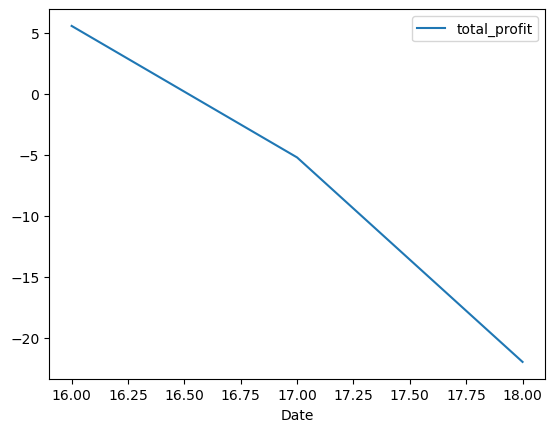

In [19]:
daily_profit.plot(x="Date",y="total_profit")
plt.show()